# Import Dependencies

In [3]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

In [4]:
import joblib
import matplotlib.pyplot as plt
import pandas as pd
from optuna.visualization.matplotlib import plot_optimization_history
from sklearn.model_selection import train_test_split

from src.features import add_band_availability, add_cation_ratio, add_missing_indicators
from src.modeling.tuning import tune_catboost

# Load Data & Reproduksi Feature Set

In [ ]:
# Load dataset
df = pd.read_csv("../data/raw/train.csv", index_col="sample_id")
df.head()

,source_id,has_band_A_spectrum,has_band_B_spectrum,sampling_strategy,sampling_depth_cm,geo_zone_macro,geo_zone_micro,geo_zone_meso,land_cover_type,biome,...,spectral_band_B_PC_6,spectral_band_B_PC_7,spectral_band_B_PC_8,spectral_band_B_PC_9,spectral_band_B_PC_10,spectral_band_B_PC_11,spectral_band_B_PC_12,spectral_band_B_PC_13,spectral_band_B_PC_14,spectral_band_B_PC_15
sample_id,,,,,,,,,,,,,,,,,,,,,
train_00001,Source_01,YES,NO,Auger,0-20,SE,Unknown,State_01,Seasonal Semideciduous Forest,Mata Atlantica,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
train_00002,Source_10,YES,NO,Auger,0-20,MW,Loc_011,State_10,Savannah,Cerrado,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
train_00003,Source_04,YES,NO,Auger,0-20,S,Loc_001,State_06,Unknown,Unknown,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
train_00004,Source_02,YES,NO,Auger,0-20,N,Unknown,State_07,Unknown,Amazonia,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
train_00005,Source_04,YES,NO,Auger,0-20,S,Loc_001,State_06,Unknown,Unknown,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
# Pembuatan fitur-fitur tambahan
df = add_missing_indicators(df)
df = add_band_availability(df)
df = add_cation_ratio(df)

In [7]:
# Split dataset
X = df.drop(columns="property_organic_content")
y = df["property_organic_content"]

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, stratify=X["source_id"], random_state=42)
X_train.shape, X_val.shape, y_train.shape, y_val.shape

((8968, 59), (2242, 59), (8968,), (2242,))

In [8]:
# Categorical fetures
cat_feats = X_train.select_dtypes(
    include=['object', 'category']
).columns.tolist()

# Jalankan Optuna Study

In [ ]:
study = tune_catboost(X=X_train, y=y_train, cat_feats=cat_feats, n_trials=50, n_splits=3)

[I 2026-06-29 04:59:48,432] A new study created in memory with name: no-name-65d60cbb-d2e4-4d19-ba5c-ff1f00164de7
[I 2026-06-29 05:00:55,526] Trial 0 finished with value: 12.920224456354871 and parameters: {'bootstrap_type': 'Bernoulli', 'learning_rate': 0.03143705862373023, 'depth': 3, 'min_data_in_leaf': 50, 'subsample': 0.9525094213387115}. Best is trial 0 with value: 12.920224456354871.
[I 2026-06-29 05:01:12,766] Trial 1 finished with value: 16.200305265509716 and parameters: {'bootstrap_type': 'Bayesian', 'learning_rate': 0.00783354909169533, 'depth': 1, 'min_data_in_leaf': 23}. Best is trial 0 with value: 12.920224456354871.
[I 2026-06-29 05:02:11,762] Trial 2 finished with value: 12.152027442817436 and parameters: {'bootstrap_type': 'Bernoulli', 'learning_rate': 0.08773872388531613, 'depth': 5, 'min_data_in_leaf': 65, 'subsample': 0.7797768579002586}. Best is trial 2 with value: 12.152027442817436.
[I 2026-06-29 05:02:29,015] Trial 3 finished with value: 15.46702536362532 and p

# Diagnostik Hasil Tuning

/tmp/ipykernel_23/1997897459.py:6: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  plot_optimization_history(study)


Best RMSE : 11.933022
Best params:
--> bootstrap_type: Bayesian
--> learning_rate: 0.08966956777379233
--> depth: 9
--> min_data_in_leaf: 81


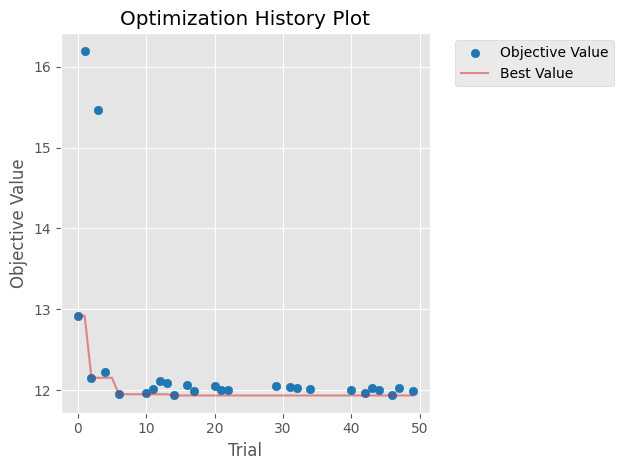

In [10]:
print("Best RMSE :", round(study.best_value, 6))
print("Best params:")
for k, v in study.best_params.items():
    print(f"--> {k}: {v}")

plot_optimization_history(study)
plt.tight_layout()
plt.show()

# Simpan Hasil Study

In [ ]:
Path("../outputs").mkdir(exist_ok=True)
joblib.dump(study, "../outputs/study.pkl")

['outputs/study.pkl']